# RR1 library-preparation interaction benchmark

## Primary question

Is the RR1 OSD-48→OSD-168 reversal explained by a common PolyA→ribodepletion displacement, or does the protocol transition modify the estimated FLT−GC response itself?

This benchmark reuses exact animal mappings and frozen Task 3/4 assets. In RR1, OSD, PolyA/ribodepletion, read layout/length/depth, preservation, and processing change together. We therefore test a **protocol-associated prep×flight interaction** and do not assign causality to library selection alone.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if not (ROOT/'results').exists():ROOT=ROOT/'benchmarks/rr1_library_prep_interaction'
R=ROOT/'results';pd.set_option('display.max_colwidth',120)
summary=pd.read_csv(R/'summary/multiscale_interaction_summary.csv')
decision=json.loads((R/'summary/decision.json').read_text())

## 1. Exact sample matching

Only the OSD-48 carcass stratum has an OSD-168 counterpart. The analysis uses four matched FLT animals (M25, M26, M28, M30) and five matched GC animals (M36–M40). M27 is excluded because it lacks an OSD-168 counterpart. The OSD-48 upon-euthanasia animals have no OSD-168 remeasurement and are analyzed only as a handling sensitivity, not pooled into the primary comparison. Same animal/liver is established; identical RNA aliquot across OSD-48 and OSD-168 is not.

In [2]:
mapping=pd.read_csv(R/'manifest/exact_animal_mapping.csv')
display(mapping[mapping.cohort.eq('RR1')][['measurement','OSD','condition','animal_id','sample_id','library_preparation','sequencing_parameters','preservation']])

,measurement,OSD,condition,animal_id,sample_id,library_preparation,sequencing_parameters,preservation
0,original,OSD-48,FLT,M25,Mmus_C57-6J_LVR_FLT_C_Rep1_M25,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
1,original,OSD-48,FLT,M26,Mmus_C57-6J_LVR_FLT_C_Rep2_M26,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
2,original,OSD-48,FLT,M28,Mmus_C57-6J_LVR_FLT_C_Rep4_M28,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
3,original,OSD-48,FLT,M30,Mmus_C57-6J_LVR_FLT_C_Rep5_M30,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
4,original,OSD-48,GC,M36,Mmus_C57-6J_LVR_GC_C_Rep1_M36,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
5,original,OSD-48,GC,M37,Mmus_C57-6J_LVR_GC_C_Rep2_M37,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
6,original,OSD-48,GC,M38,Mmus_C57-6J_LVR_GC_C_Rep3_M38,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
7,original,OSD-48,GC,M39,Mmus_C57-6J_LVR_GC_C_Rep4_M39,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
8,original,OSD-48,GC,M40,Mmus_C57-6J_LVR_GC_C_Rep5_M40,polyA,SE 50bp 30M,Mini Cold Bag to -80C freezer
9,remeasure,OSD-168,FLT,M25,Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep1_M25,ribodepleted,PE 150bp 100M,Liquid Nitrogen


## 2. Four-effect decomposition

For every vector representation:

`Flight_PolyA = FLT_PolyA − GC_PolyA`

`Flight_Ribo = FLT_Ribo − GC_Ribo`

`Prep_FLT = FLT_Ribo − FLT_PolyA`

`Prep_GC = GC_Ribo − GC_PolyA`

`Interaction = Prep_FLT − Prep_GC = Flight_Ribo − Flight_PolyA`

The matched-animal exact permutation test reassigns the nine observed animal-level prep displacements to groups of four versus five. It tests whether the FLT/GC difference in prep displacement is unusually large; it cannot identify which co-changing protocol variable caused it.

In [3]:
cols=['representation','flight_response_agreement','prep_FLT_vs_GC_cosine','interaction_norm','interaction_to_mean_prep_ratio','interaction_exact_permutation_p']
display(summary[cols].style.format({c:'{:.3f}' for c in cols if c!='representation'},na_rep='—'))

,representation,flight_response_agreement,prep_FLT_vs_GC_cosine,interaction_norm,interaction_to_mean_prep_ratio,interaction_exact_permutation_p
0,expression,0.369,0.962,26.772,0.347,0.016
1,pca,0.369,0.962,26.772,0.347,0.016
2,global,-0.804,0.996,1.353,0.407,0.016
3,l12_mean_sd,-0.785,0.995,1.357,0.406,0.016
4,hallmark,-0.416,0.994,9.898,0.381,0.016
5,graph,0.172,0.750,109.946,0.711,—
6,attribution,0.727,—,0.059,—,—


### Primary finding

The FLT and GC prep displacements point in nearly the same direction for expression, global, L12 mean+SD, and Hallmark representations (cosine 0.962–0.996): there is a large common protocol displacement. However, their difference is not negligible. The interaction is 35–41% of the mean prep-displacement magnitude in the conventional/global/program vector spaces and is tied only by the observed allocation and its complement among 126 exhaustive condition-label permutations (`p = 2/126 = 0.0159`). Thus, a common shift exists **and** the protocol transition modifies the estimated FLT−GC response.

The modification is consequential: global BridgeRNA FLT−GC agreement reverses (−0.804), L12 mean+SD is −0.785, and Hallmark module response is −0.416. Signed input-gene IG attribution retains positive cosine (0.727) despite low genome-wide rank reproducibility, while expression and graph agreement remain only partially positive. IG should not be confused with the separate contextual-token PC1–2 projection metric.

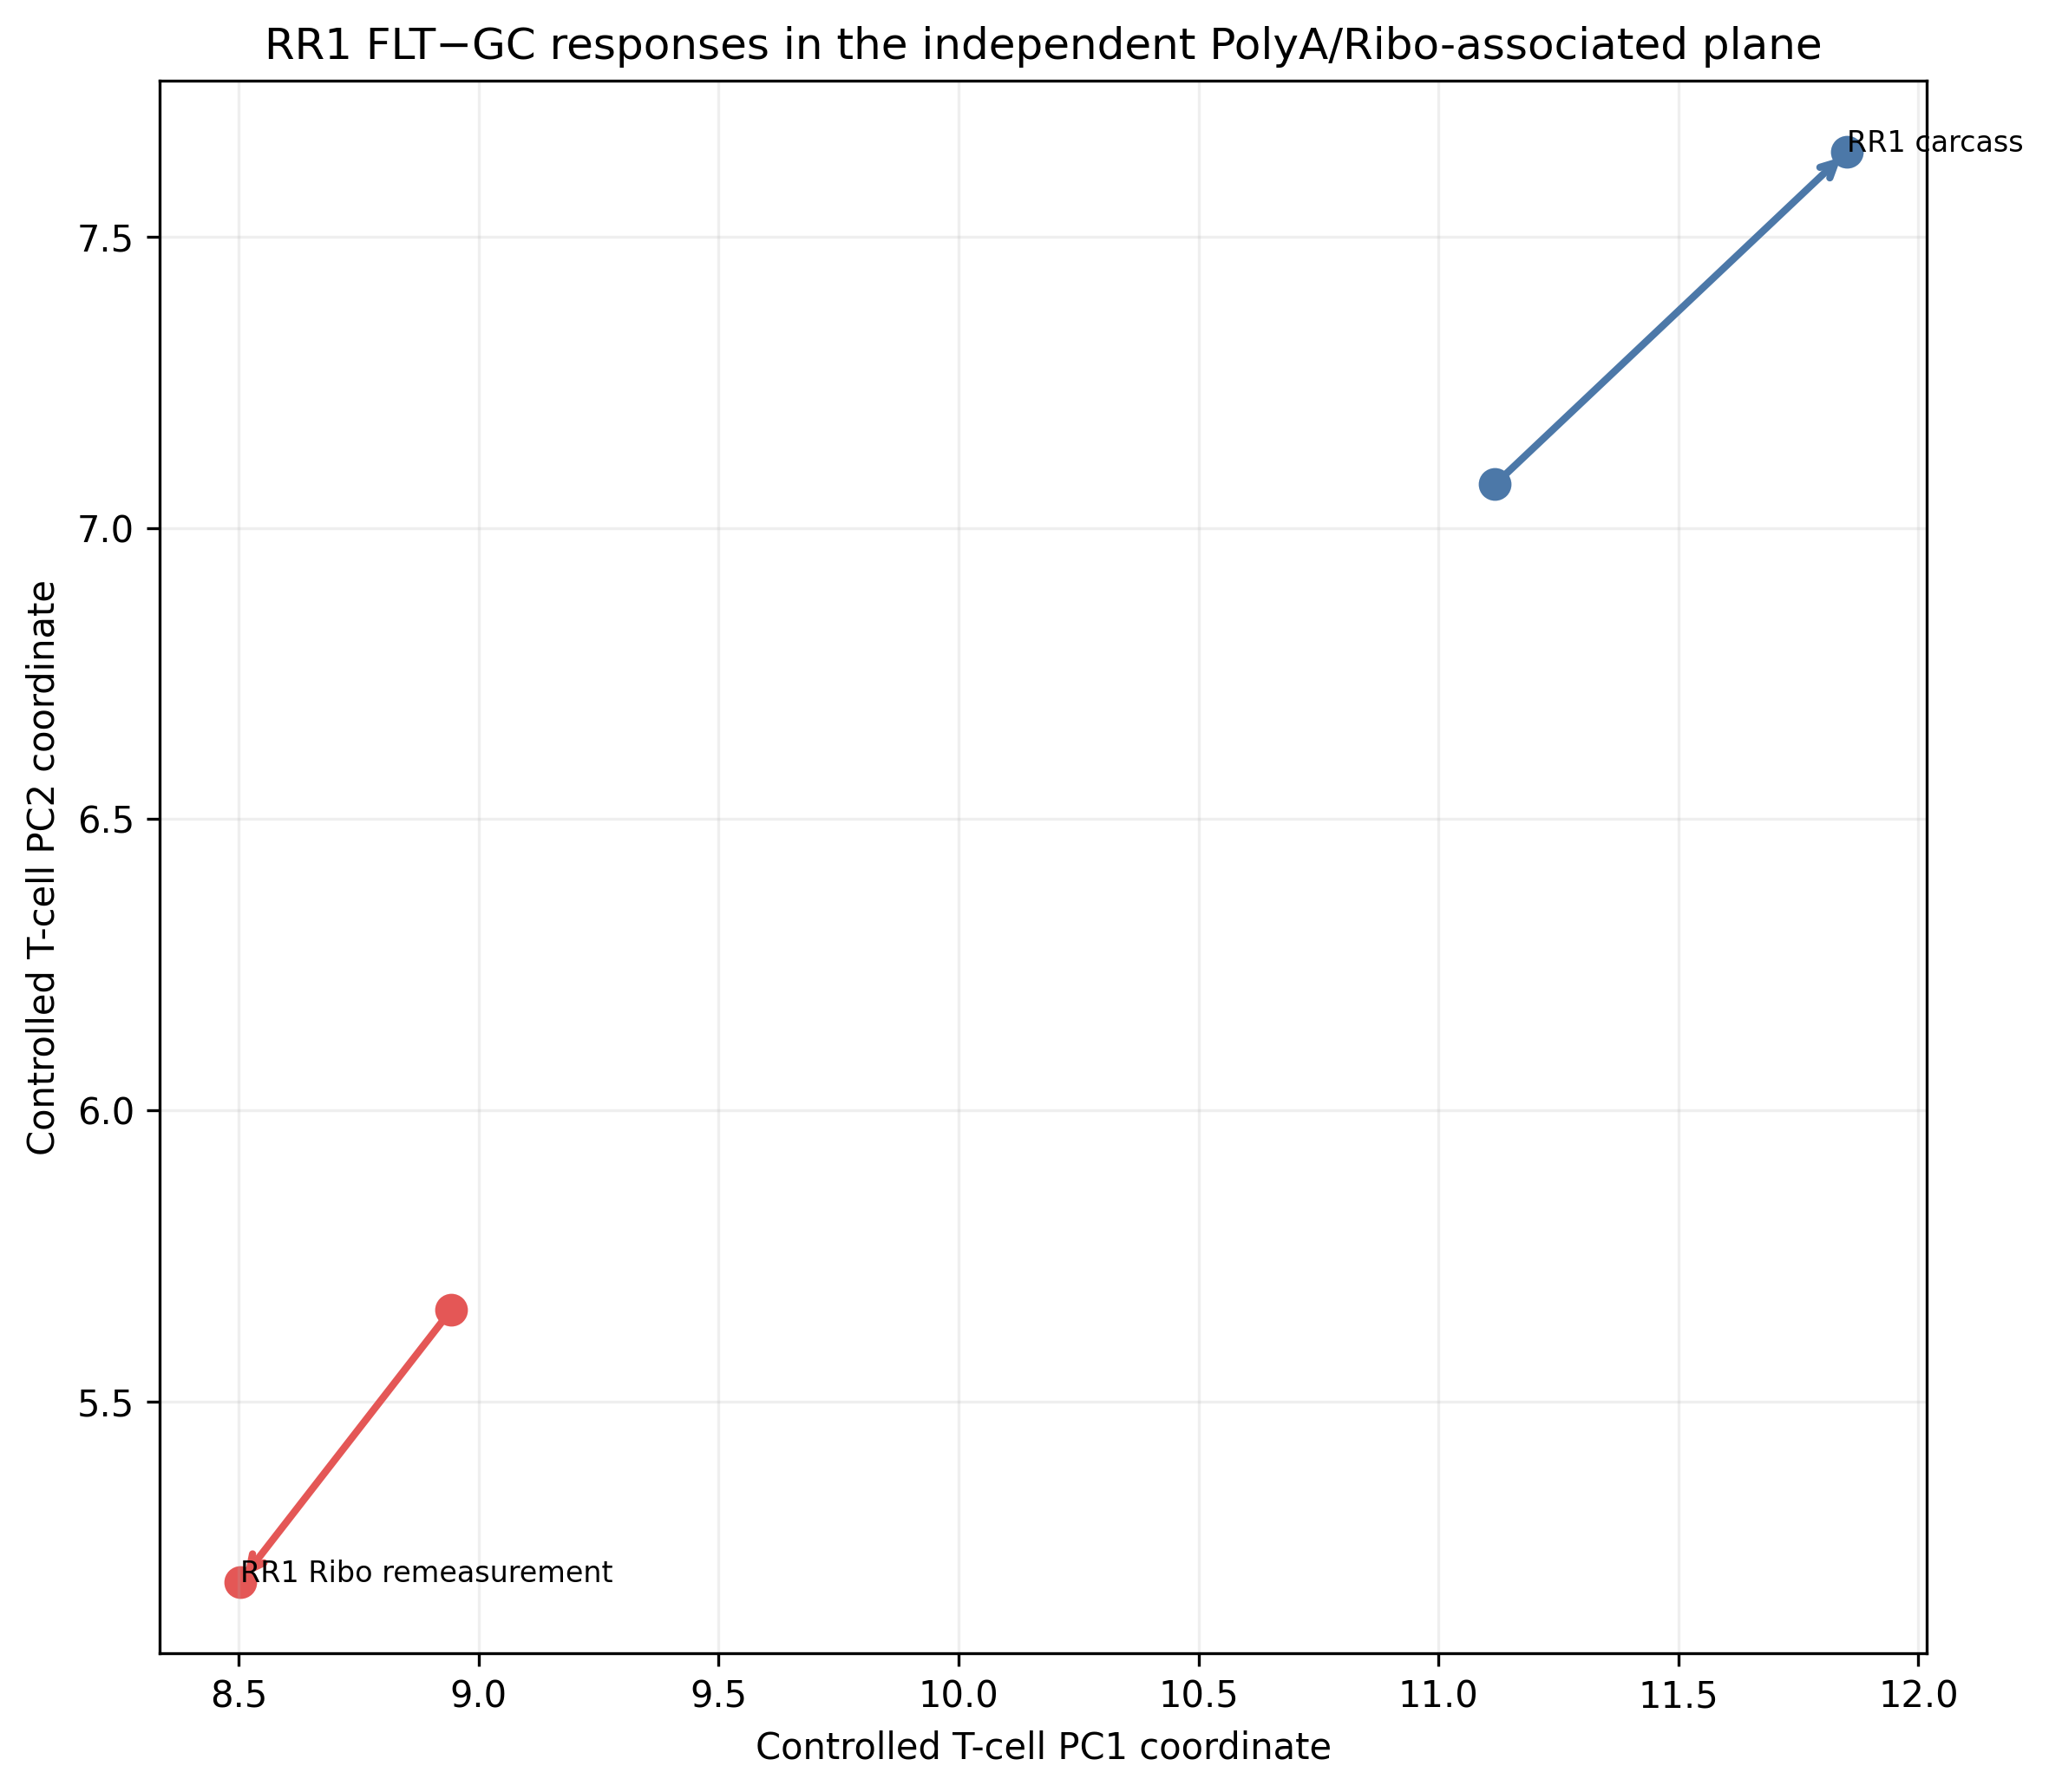

In [4]:
display(Image(filename=str(R/'figures/critical_decomposition.png')))

## 3. Independent T-cell PolyA→Ribo reference

The controlled same-RNA T-cell experiment defines an external technical direction separately in each mathematically compatible space. Projection is diagnostic, not causal attribution. PCA is fit once on all Task 3 samples and then used to transform T-cell profiles; no RR1 outcome is used to choose the direction.

In [5]:
cols=['representation','prep_FLT_tcell_alignment_cosine','prep_GC_tcell_alignment_cosine','interaction_tcell_alignment_cosine','interaction_projected_energy_fraction','flight_response_agreement','flight_response_agreement_after_removal']
display(summary[cols].style.format({c:'{:.3f}' for c in cols if c!='representation'},na_rep='—'))

,representation,prep_FLT_tcell_alignment_cosine,prep_GC_tcell_alignment_cosine,interaction_tcell_alignment_cosine,interaction_projected_energy_fraction,flight_response_agreement,flight_response_agreement_after_removal
0,expression,0.350,0.375,0.150,0.023,0.369,0.378
1,pca,0.680,0.728,0.291,0.085,0.369,0.402
2,global,0.782,0.803,0.720,0.519,-0.804,-0.709
3,l12_mean_sd,—,—,—,—,-0.785,—
4,hallmark,—,—,—,—,-0.416,—
5,graph,0.003,0.003,0.000,0.000,0.172,0.172
6,attribution,—,—,0.016,0.000,0.727,—


The global RR1 prep displacements align strongly with the T-cell direction (FLT 0.782; GC 0.803), and 51.9% of the global interaction energy lies along that single mean direction. Removing it improves global response cosine only from −0.804 to −0.709; it does not restore reproducibility. Expression improves from 0.369 to 0.378 and PCA to 0.402. The graph-level T-cell displacement is nearly orthogonal to the RR1 graph interaction and removal has essentially no effect.

Therefore, a generic controlled prep direction explains part of the interaction, but not the RR1 reversal. This is consistent with the earlier PC1–2 analysis: removing broader technical-associated structure can improve RR1 further, but at the cost of reorganizing biological response geometry.

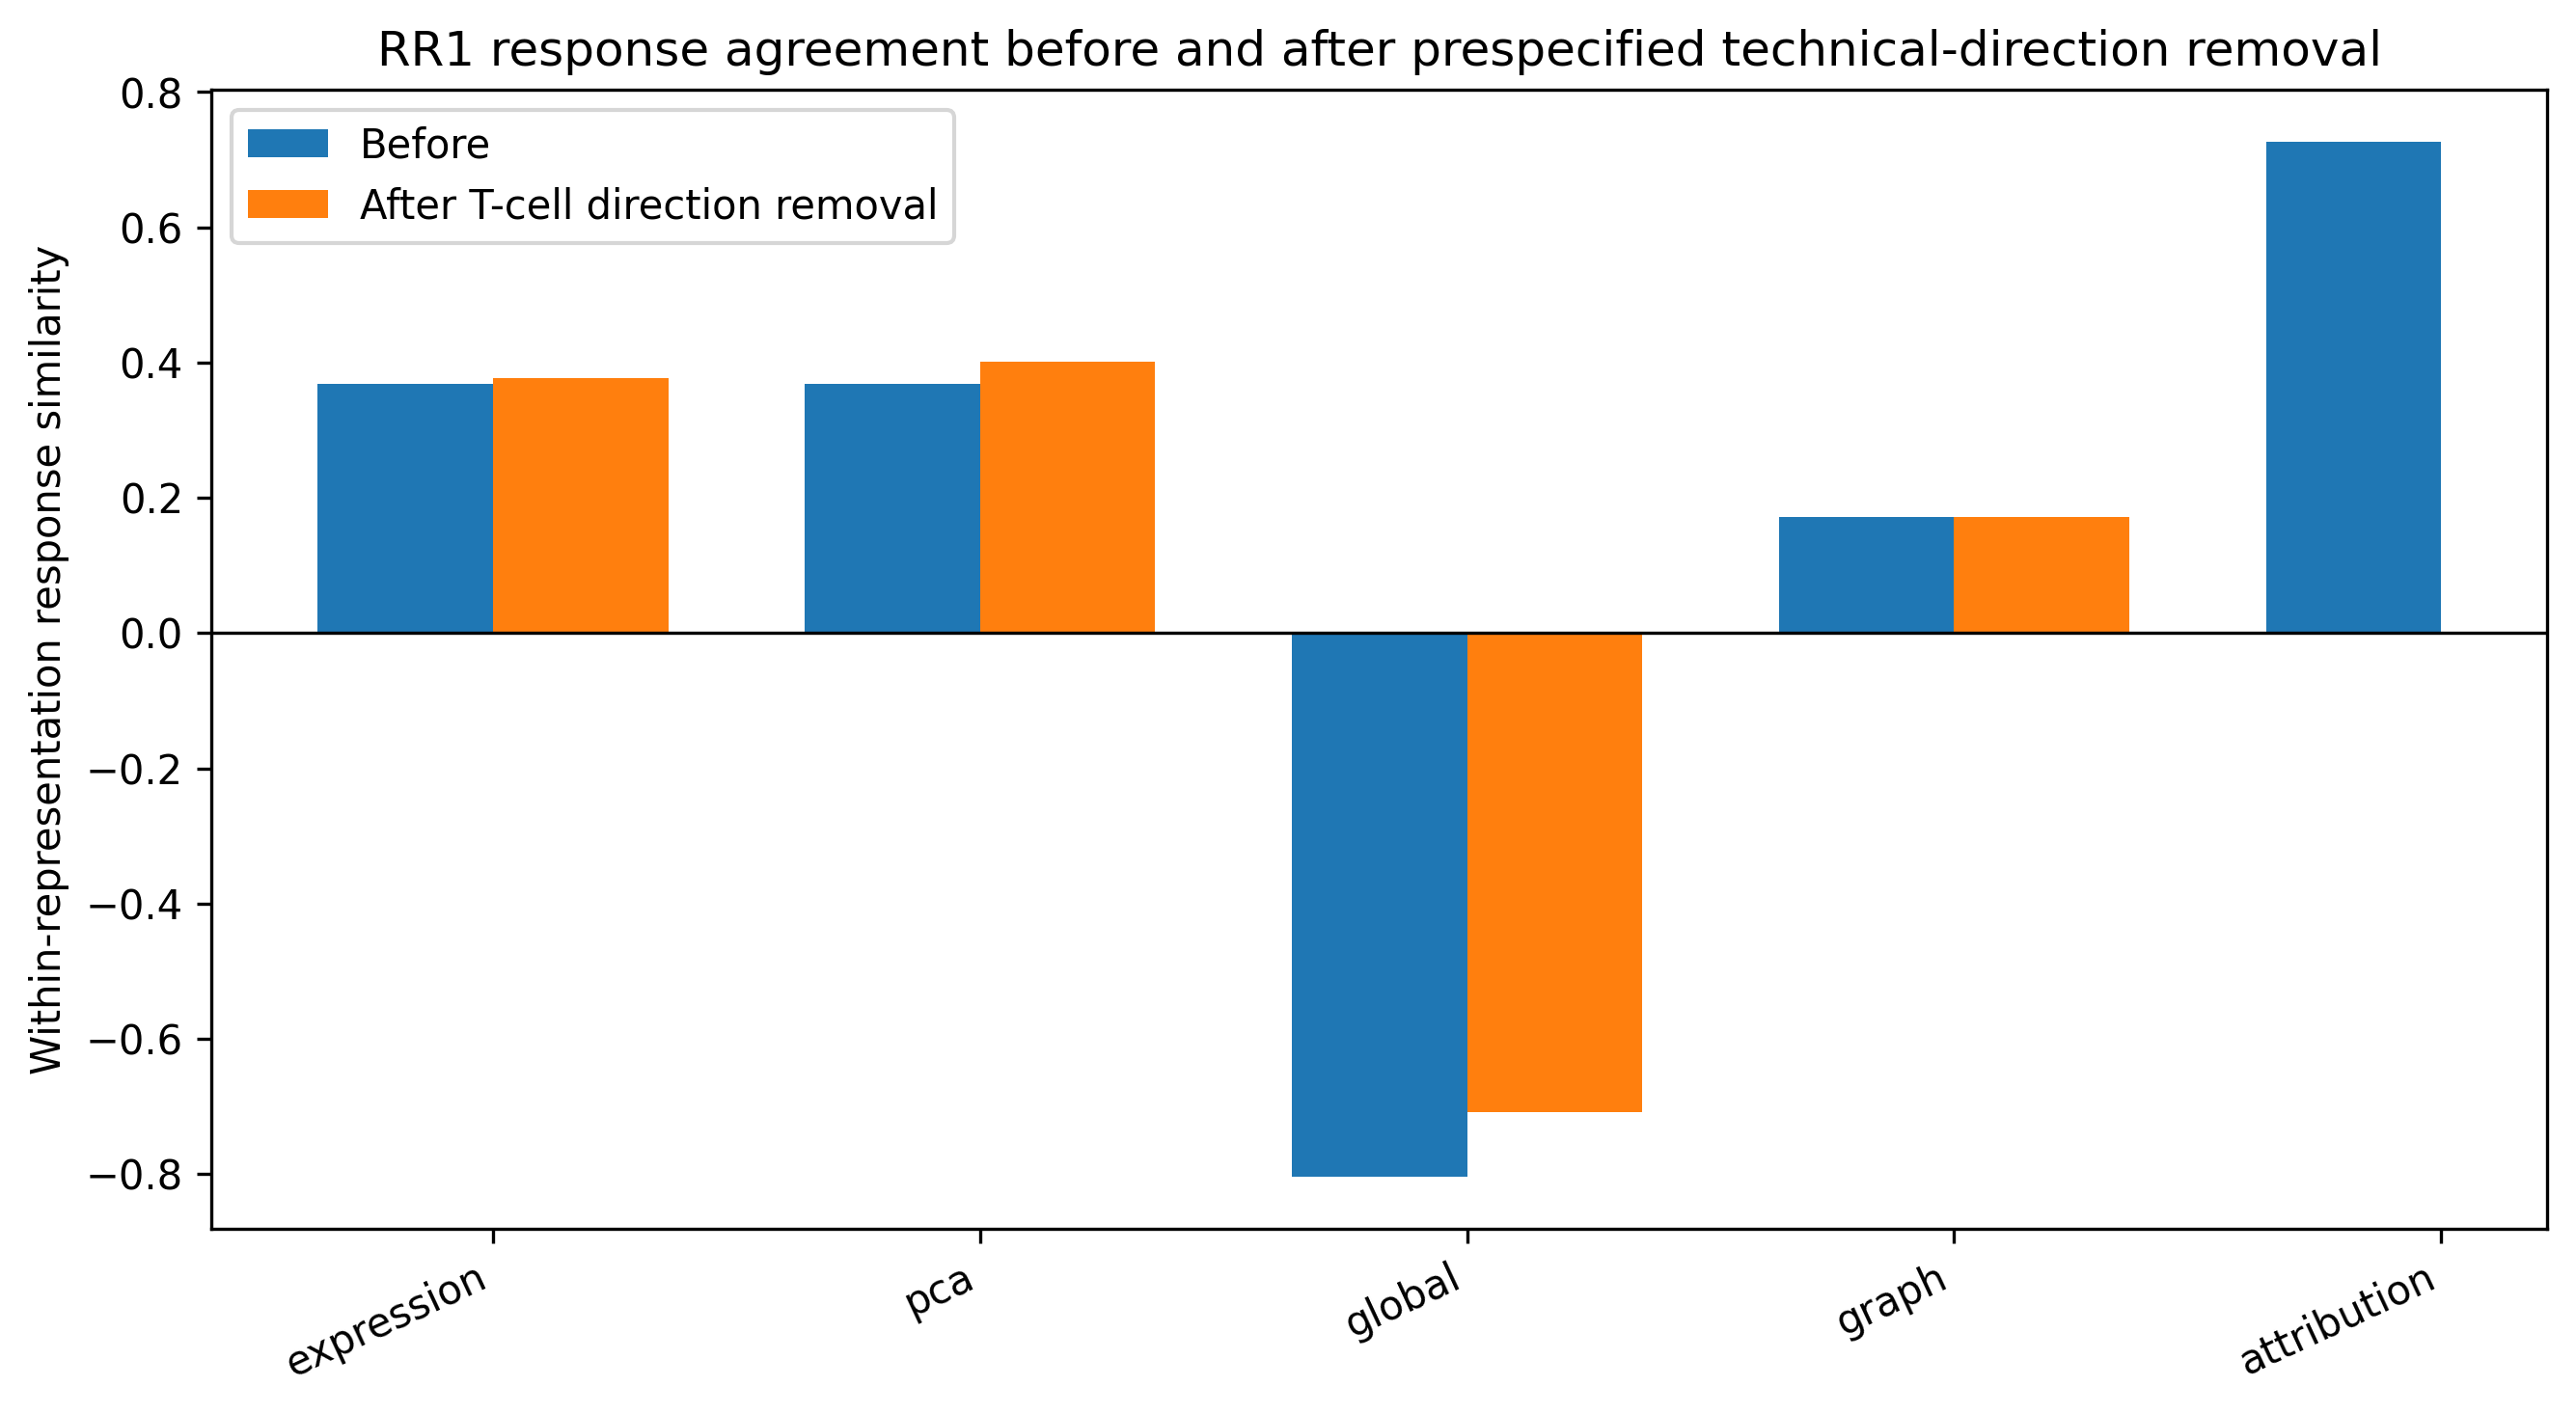

In [6]:
display(Image(filename=str(R/'figures/before_after_residualization.png')))

## 4. Genes and programs localizing the interaction

The gene table uses the exact 15,165-gene log1p(TPM) model input—not manufactured counts. It reports the expression interaction, sign flips, existing response IG values, and graph-interaction neighborhood magnitude. These are effect-size diagnostics rather than a new DE test.

In [7]:
genes=pd.read_parquet(R/'interaction/per_gene_interaction.parquet')
display(genes.head(25).style.format({c:'{:.3f}' for c in genes.select_dtypes('number').columns}))

,gene_symbol,polyA_FLT_minus_GC,ribo_FLT_minus_GC,expression_interaction,sign_flip,RR1_OSD168_no-ERCC,RR1_OSD48_original_matched,graph_interaction_norm,absolute_interaction_rank
0,SNURF,-0.567,0.426,0.994,True,0.000,-0.000,1.592,1.000
1,MTCP1,-0.523,0.432,0.955,True,-0.000,0.000,2.078,2.000
2,FUBP1,-0.449,0.421,0.870,True,-0.000,0.000,2.284,3.000
3,ZNF169,-0.558,0.288,0.846,True,-0.000,0.000,2.896,4.000
4,PLIN4,-0.358,0.477,0.835,True,-0.001,0.001,1.465,5.000
5,SLC34A2,0.813,1.627,0.813,False,-0.001,-0.001,1.150,6.000
6,MROH6,-0.576,0.217,0.793,True,-0.000,0.000,1.652,7.000
7,ZGPAT,-0.497,0.294,0.791,True,-0.000,0.000,1.645,8.000
8,TTC14,-0.264,0.519,0.784,True,-0.000,0.000,1.430,9.000
9,PSTPIP2,-0.272,0.511,0.783,True,-0.000,0.000,1.558,10.000


In [8]:
enrich=pd.read_csv(R/'interaction/top250_interaction_enrichment.csv')
display(enrich.head(20).style.format({'p_value':'{:.2e}','fdr':'{:.2e}'}))

,term,overlap,set_size,p_value,fdr
0,GO BP: MRNA Processing (GO:0006397),24,239,1.38e-12,2.27e-09
1,GO BP: Regulation of RNA Splicing (GO:0043484),16,93,2.26e-12,2.27e-09
2,"GO BP: Regulation of mRNA Splicing, via Spliceosome (GO:0048024)",16,98,5.24e-12,3.50e-09
3,"GO BP: Regulation of Alternative mRNA Splicing, via Spliceosome (GO:0000381)",12,63,3.92e-10,1.97e-07
4,"GO BP: MRNA Splicing, via Spliceosome (GO:0000398)",18,207,9.75e-09,3.91e-06
5,GO BP: MRNA Splice Site Recognition (GO:0006376),8,29,1.55e-08,5.07e-06
6,GO BP: Regulation of Primary Metabolic Process (GO:0080090),13,105,1.77e-08,5.07e-06
7,"GO BP: RNA Splicing, via Transesterification Reactions With Bulged Adenosine as Nucleophile (GO:0000377)",16,171,2.35e-08,5.89e-06
8,GO BP: RNA Processing (GO:0006396),20,297,1.08e-07,2.40e-05
9,Reactome: mRNA Splicing,16,192,1.19e-07,2.40e-05


The strongest interaction genes include SNURF, MTCP1, FUBP1, ZNF169, PLIN4, SLC34A2, PFKFB2, and OGT. The post hoc Top-250 enrichment is dominated by mRNA processing, splice-site recognition, spliceosomal regulation, and related RNA-metabolic programs. This supports protocol sensitivity of RNA-processing measurements, but it does not establish that these pathways are artifacts or that library selection is the only cause.

## 5. Handling and RNA quality

The upon-euthanasia stratum cannot be technically replicated because OSD-168 lacks corresponding animals. It therefore cannot adjudicate the primary matched comparison. Existing RIN interaction models are descriptive and cohort-confounded; neither PC1 nor PC2 shows evidence of an FLT/GC-by-RIN interaction.

In [9]:
strata=pd.read_csv(R/'handling/stratum_replication.csv');display(strata)
rin=pd.read_csv(R/'handling/rin_and_condition_diagnostics.csv');display(rin[rin.analysis.str.contains('RIN')])

,stratum,valid,OSD48_n_FLT,OSD48_n_GC,OSD168_n_FLT,OSD168_n_GC,whole_cosine,parallel_cosine,outside_PC1_2_cosine,OSD48_aligned_fraction,OSD168_aligned_fraction,discrepancy_fraction_PC1_2,reason
0,carcass (exact matched animals; no-ERCC OSD-168),True,4,5,4,5,-0.804119,-0.974401,0.221041,0.93274,0.779807,0.953069,This is the original -0.804 comparison; M27 was excluded because OSD-168 has no matched M27 profile.
1,upon euthanasia,False,2,2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,OSD-168 contains no corresponding M21/M22/M31/M32 profiles; component replication metrics are undefined.


,analysis,outcome,term,coefficient,SE,p_value,n_profiles,note
8,FLT_GC × RIN descriptive,TCell_PC1_score,Intercept,8.480093,1.938346,0.000062,54,cohort-confounded; not causal
9,FLT_GC × RIN descriptive,TCell_PC1_score,C(condition)[T.GC],0.388705,2.994566,0.897243,54,cohort-confounded; not causal
10,FLT_GC × RIN descriptive,TCell_PC1_score,RIN_numeric,0.124918,0.235835,0.598674,54,cohort-confounded; not causal
11,FLT_GC × RIN descriptive,TCell_PC1_score,C(condition)[T.GC]:RIN_numeric,-0.039944,0.368128,0.914029,54,cohort-confounded; not causal
12,FLT_GC × RIN descriptive,TCell_PC2_score,Intercept,5.731521,1.395597,0.000148,54,cohort-confounded; not causal
13,FLT_GC × RIN descriptive,TCell_PC2_score,C(condition)[T.GC],-0.058960,2.156070,0.978292,54,cohort-confounded; not causal
14,FLT_GC × RIN descriptive,TCell_PC2_score,RIN_numeric,0.033097,0.169800,0.846249,54,cohort-confounded; not causal
15,FLT_GC × RIN descriptive,TCell_PC2_score,C(condition)[T.GC]:RIN_numeric,0.019015,0.265050,0.943095,54,cohort-confounded; not causal


## 6. RR3 positive controls

RR3 was never used to define the T-cell direction. Its role is to show that technical remeasurement can remain reproducible in the same overall project. RR3-39 and RR3-40 retain global response cosines of 0.790 and 0.917; their program and attribution agreement are also much stronger than RR1. RR3-40 is the cleanest control because it remains concordant across every tested scale.

In [10]:
controls=pd.read_csv(R/'summary/rr1_rr3_multiscale_controls.csv')
display(controls.pivot(index='comparison',columns='representation',values='similarity').style.format('{:.3f}'))

representation,Bridge mean,Graph signed-edge response,Hallmark mean+SD,PCA-15165,Raw expression
comparison,,,,,
RR1,-0.807,0.183,-0.424,-0.206,0.369
RR3-39,0.790,0.319,0.775,0.790,0.652
RR3-40,0.917,0.399,0.922,0.914,0.822
false_friend,0.811,0.012,0.510,0.361,0.121


# Protocol-robust core RR1 response

The complete RR1 vectors are unstable, but that does not imply every gene or program is unstable. This section identifies evidence that survives both measurements without forcing the complete vectors to agree.

The primary gene-level definition is transparent and prespecified:

- **Robust expression:** mutual Top-500 absolute response and the same direction.
- **Robust attribution:** mutual Top-500 absolute signed IG and the same direction.
- **Robust contextual neighborhood:** Top-500 per-gene local graph similarity with positive concordance.
- **Multilevel candidate:** support from at least two of these three independent readouts.

Top-100 and Top-250 sensitivity results are retained separately. The evidence count is not learned or weighted.

In [11]:
CORE=R/'robust_core'
sizes=pd.read_csv(CORE/'rr3_controls/robust_core_size.csv')
metrics=pd.read_csv(CORE/'rr3_controls/multilevel_reproducibility.csv')
overlap=pd.read_csv(CORE/'rr3_controls/topn_overlap.csv')
display(sizes)
display(metrics.style.format({c:'{:.3f}' for c in metrics.select_dtypes('number').columns},na_rep='—'))
display(overlap.style.format({'direction_agreement':'{:.1%}'}))

,cohort,genes_2plus_evidence,genes_3of3_evidence,robust_expression,robust_attribution,robust_graph
0,RR1,114,26,179,246,476
1,RR3-39,104,15,262,332,482
2,RR3-40,172,31,381,357,483


,cohort,pearson,spearman,cosine,genome_direction_agreement,level,median_local_cosine,positive_local_fraction
0,RR1,0.645,0.425,0.369,0.464,expression,—,—
1,RR1,0.735,0.194,0.727,0.480,attribution,—,—
2,RR1,—,—,—,—,graph_local,0.138,0.757
3,RR3-39,0.646,0.618,0.652,0.710,expression,—,—
4,RR3-39,0.866,0.601,0.867,0.712,attribution,—,—
5,RR3-39,—,—,—,—,graph_local,0.340,0.830
6,RR3-40,0.823,0.673,0.822,0.710,expression,—,—
7,RR3-40,0.725,0.597,0.725,0.694,attribution,—,—
8,RR3-40,—,—,—,—,graph_local,0.386,0.840


,cohort,top_n,overlap,direction_agreement,level
0,RR1,100,46,100.0%,expression
1,RR1,250,97,100.0%,expression
2,RR1,500,181,98.9%,expression
3,RR1,100,53,96.2%,attribution
4,RR1,250,154,89.0%,attribution
5,RR1,500,284,86.6%,attribution
6,RR3-39,100,58,100.0%,expression
7,RR3-39,250,150,98.0%,expression
8,RR3-39,500,266,98.5%,expression
9,RR3-39,100,71,98.6%,attribution


## RR1 robust-core size

RR1 contains **179** robust-expression genes, **246** robust-IG genes, and **476** locally stable graph genes under the Top-500 definitions. Their intersections yield **114 genes supported by at least two levels**, including **26 supported by all three**.

At Top-100, expression shares 46 genes with 100% sign agreement, while IG shares 53 genes with 96.2% sign agreement. Genome-wide expression Spearman is 0.425; IG Spearman is only 0.194 despite cosine 0.727, showing that a concentrated common direction coexists with extensive rank reweighting.

In [12]:
candidates=pd.read_csv(CORE/'integrated/protocol_robust_candidates.csv')
cols=['gene_symbol','evidence_count','expression_original','expression_remeasurement','attribution_original','attribution_remeasurement','graph_local_cosine','absolute_interaction_rank','handling_sensitive','tcell_top500','interpretation']
display(candidates[cols].head(40).style.format({c:'{:.3f}' for c in cols if c not in ['gene_symbol','evidence_count','handling_sensitive','tcell_top500','interpretation']}))

,gene_symbol,evidence_count,expression_original,expression_remeasurement,attribution_original,attribution_remeasurement,graph_local_cosine,absolute_interaction_rank,handling_sensitive,tcell_top500,interpretation
0,PER3,3,-2.015,-1.429,0.002,0.001,0.712,128.000,True,False,protocol-robust multilevel candidate
1,TNS2,3,-0.951,-0.553,-0.002,-0.001,0.609,938.000,True,False,protocol-robust multilevel candidate
2,DBP,3,-3.393,-2.997,0.003,0.002,0.609,966.000,True,False,protocol-robust multilevel candidate
3,CHKA,3,0.996,1.354,-0.002,-0.002,0.707,1439.000,True,False,protocol-robust multilevel candidate
4,PPP1R3B,3,0.508,0.840,-0.001,-0.002,0.711,1902.000,True,False,protocol-robust multilevel candidate
5,MFSD2A,3,-0.823,-0.496,0.001,0.001,0.710,1981.000,False,False,protocol-robust multilevel candidate
6,SLC45A3,3,0.727,1.007,-0.003,-0.004,0.752,3101.000,False,False,protocol-robust multilevel candidate
7,FMO3,3,-0.977,-0.723,0.001,0.001,0.636,3807.000,False,False,protocol-robust multilevel candidate
8,GPCPD1,3,-0.740,-0.491,0.001,0.001,0.564,3961.000,True,False,protocol-robust multilevel candidate
9,SLC22A7,3,0.567,0.815,-0.001,-0.001,0.727,3982.000,False,False,protocol-robust multilevel candidate


The 26 three-level candidates include **PER3, TNS2, DBP, CHKA, PPP1R3B, MFSD2A, SLC45A3, FMO3, GPCPD1, SLC22A7, THRSP, PLA2G12A, POR, CYP8B1, APOA5, FABP5, BNIP3, CDKN1A, HAO2, and GADD45G**. These genes span circadian regulation, hepatic transport, lipid handling, oxidation/peroxisomal biology, stress response, and intermediary metabolism.

Most are not among the independent T-cell Top-500 expression shifts. This supports—but does not prove—that the robust set differs from the generic T-cell library signature.

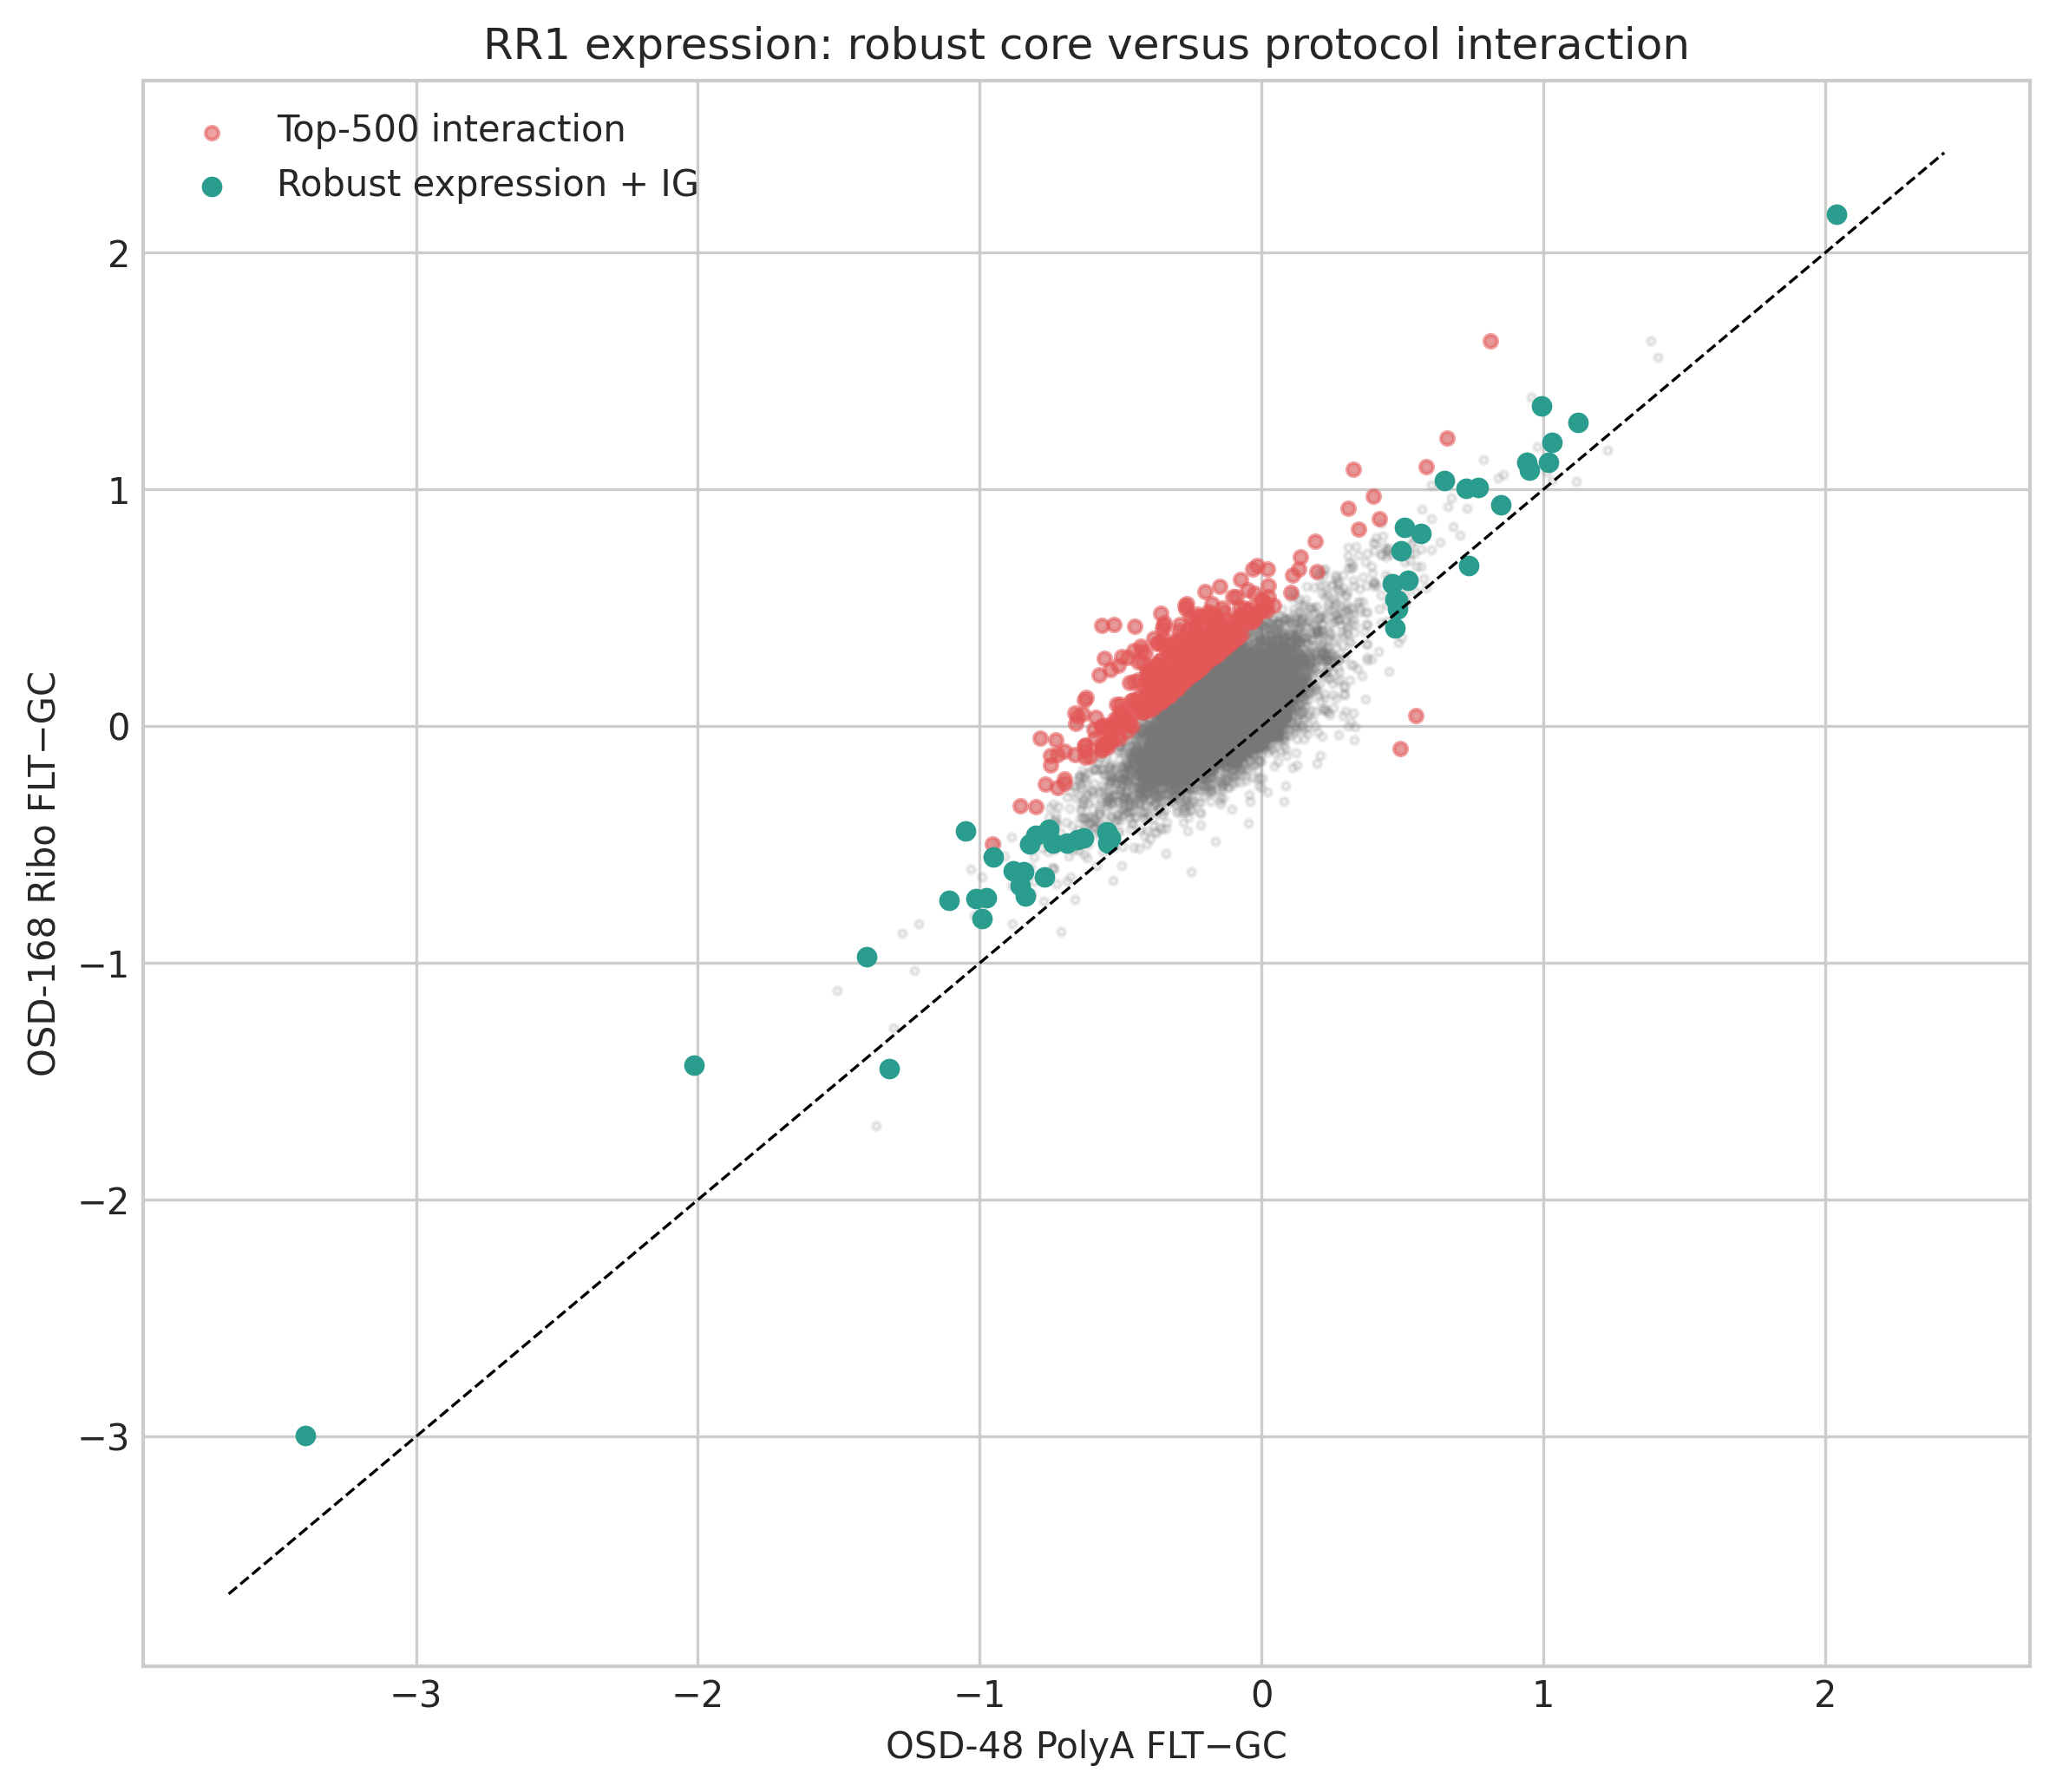

In [13]:
display(Image(filename=str(CORE/'figures/expression_robust_vs_unstable.png')))

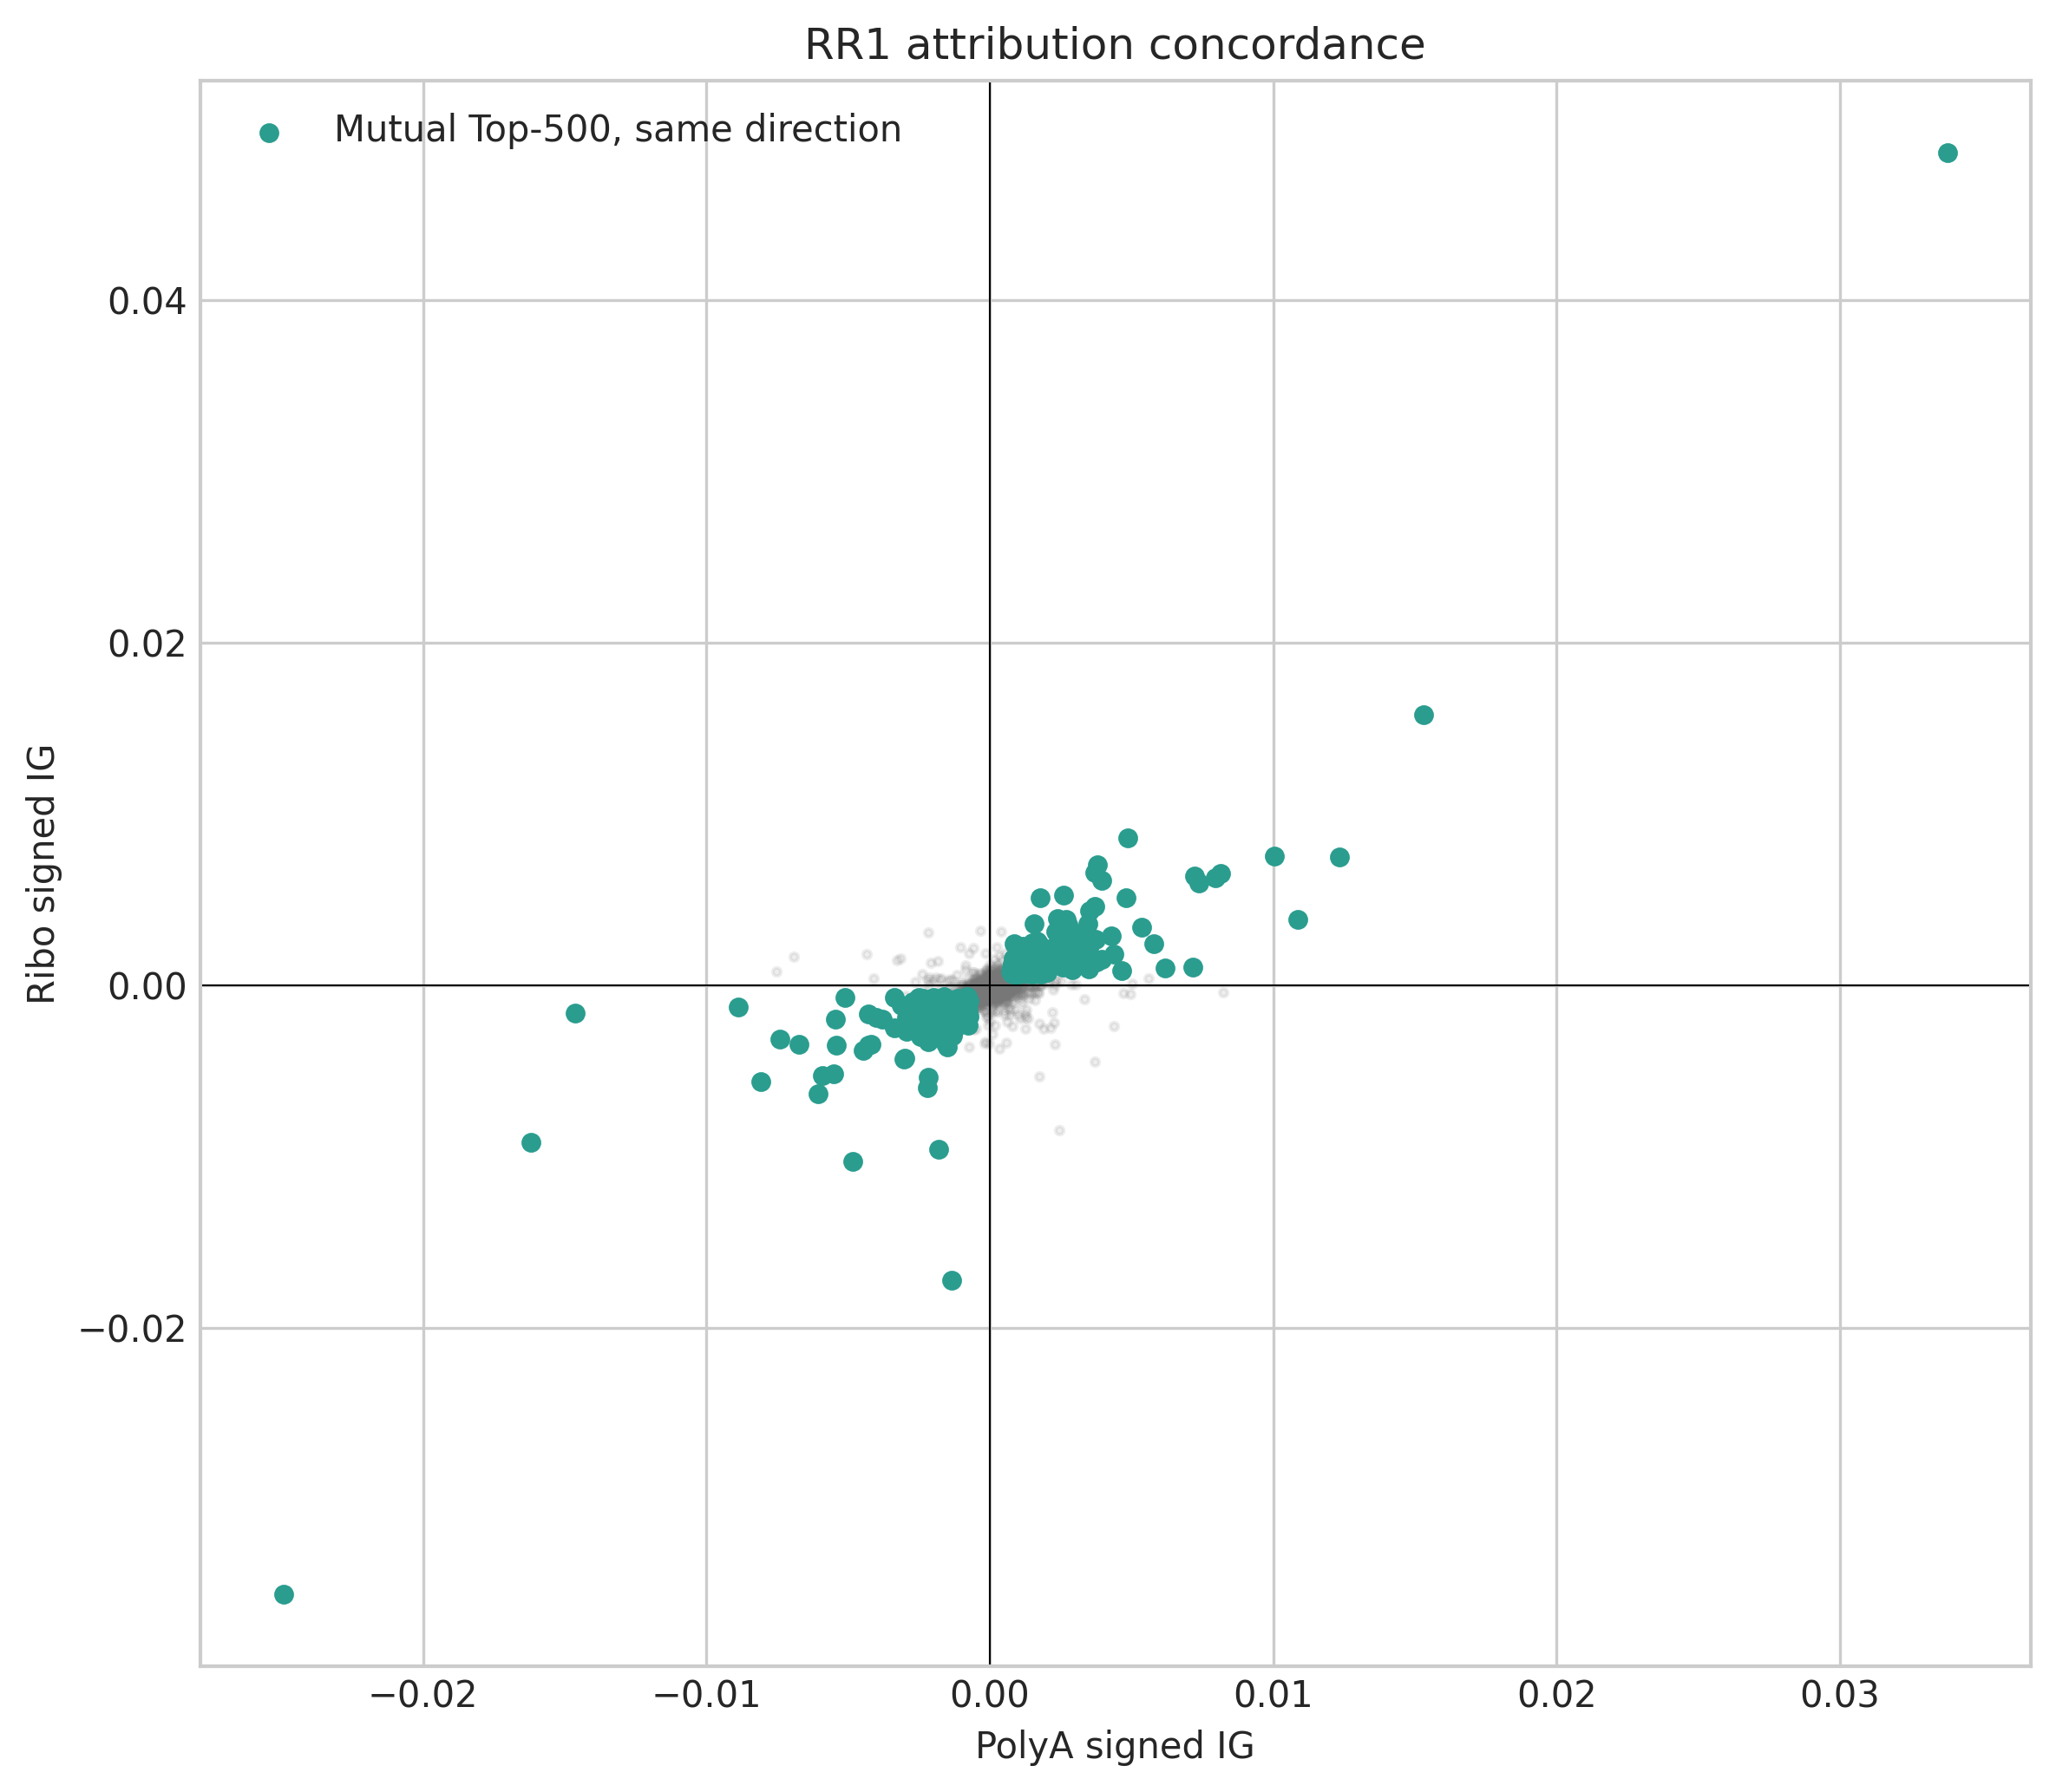

In [14]:
display(Image(filename=str(CORE/'figures/attribution_concordance.png')))

## Robust programs versus interaction programs

The multilevel robust set and the Top-500 protocol×flight interaction set were enriched separately against the exact 15,165-gene universe. The separation is biologically coherent:

- **Robust core:** lipid metabolism, circadian clock, small-molecule transport, cholesterol homeostasis, long-chain fatty-acid transport, PPARA/PPARα regulation, complement, and triglyceride metabolism.
- **Protocol-sensitive interaction:** mRNA processing, alternative splicing, splice-site recognition, and processing of capped intron-containing pre-mRNA.

Thus, the robust biology is not simply the same RNA-processing signal that dominates the disagreement, although the sets need not be perfectly separable.

In [15]:
enr=pd.read_csv(CORE/'programs/robust_vs_interaction_enrichment.csv')
display(enr.groupby('gene_set',group_keys=False).head(15).style.format({'p_value':'{:.2e}','fdr':'{:.2e}'}))
programs=pd.read_csv(CORE/'programs/rr1_program_classification.csv')
display(programs[programs.classification.eq('protocol_robust')].sort_values(['rank_polyA','rank_ribo']).head(25).style.format({'polyA_score':'{:.3f}','ribo_score':'{:.3f}'}))

,gene_set,term,overlap,set_size,p_value,fdr
0,robust_multilevel,Reactome: Metabolism of Lipids,22,673,4.77e-09,6.06e-06
1,robust_multilevel,Reactome: Circadian Clock,7,66,6.09e-07,3.87e-04
2,robust_multilevel,Reactome: Transport of Small Molecules,17,664,9.14e-06,3.19e-03
3,robust_multilevel,Hallmark: Cholesterol Homeostasis,6,70,1.40e-05,3.19e-03
4,robust_multilevel,Reactome: Terminal Pathway of Complement,3,7,1.42e-05,3.19e-03
5,robust_multilevel,GO BP: Long-chain Fatty Acid Transport (GO:0015909),4,21,1.64e-05,3.19e-03
6,robust_multilevel,Reactome: PPARA Activates Gene Expression,7,111,2.01e-05,3.19e-03
7,robust_multilevel,"GO BP: Complement Activation, GZMK Pathway (GO:0160257)",3,8,2.25e-05,3.19e-03
8,robust_multilevel,Reactome: Regulation of Lipid Metabolism by PPARalpha,7,113,2.26e-05,3.19e-03
9,robust_multilevel,"Reactome: BMAL1 CLOCK,NPAS2 Activates Circadian Gene Expression",4,24,2.87e-05,3.41e-03


,source,pathway,polyA_score,ribo_score,direction_agreement,rank_polyA,rank_ribo,classification
4601,Reactome,Protein Localization,13.409,9.068,True,1,21,protocol_robust
3250,GO:BP,Translation (GO:0006412),9.487,10.040,True,6,8,protocol_robust
5070,Reactome,Translation,9.463,8.860,True,7,23,protocol_robust
4539,Reactome,Peroxisomal Protein Import,9.041,5.275,True,11,114,protocol_robust
609,GO:BP,Fatty Acid Beta-Oxidation (GO:0006635),8.914,5.633,True,12,95,protocol_robust
613,GO:BP,Fatty Acid Catabolic Process (GO:0009062),8.771,4.758,True,13,144,protocol_robust
4377,Reactome,Mitochondrial Fatty Acid Beta-Oxidation,8.676,4.963,True,14,128,protocol_robust
3563,KEGG,PEROXISOME,8.676,5.116,True,15,121,protocol_robust
3725,Reactome,Aerobic Respiration and Respiratory Electron Transport,8.486,8.465,True,19,27,protocol_robust
997,GO:BP,Mitochondrial Gene Expression (GO:0140053),8.427,5.361,True,20,109,protocol_robust


Fifty-eight existing pathway profiles are directionally concordant and rank in the Top-250 in both measurements. Leading examples include protein localization/translation, fatty-acid β-oxidation, peroxisomal protein import and lipid metabolism, respiratory electron transport, mitochondrial gene expression, branched-chain amino-acid degradation, and the TCA cycle. Conversely, 169 prominent terms reverse direction; the whole pathway profile itself remains weakly reproducible, so the robust program subset should not be mistaken for global pathway agreement.

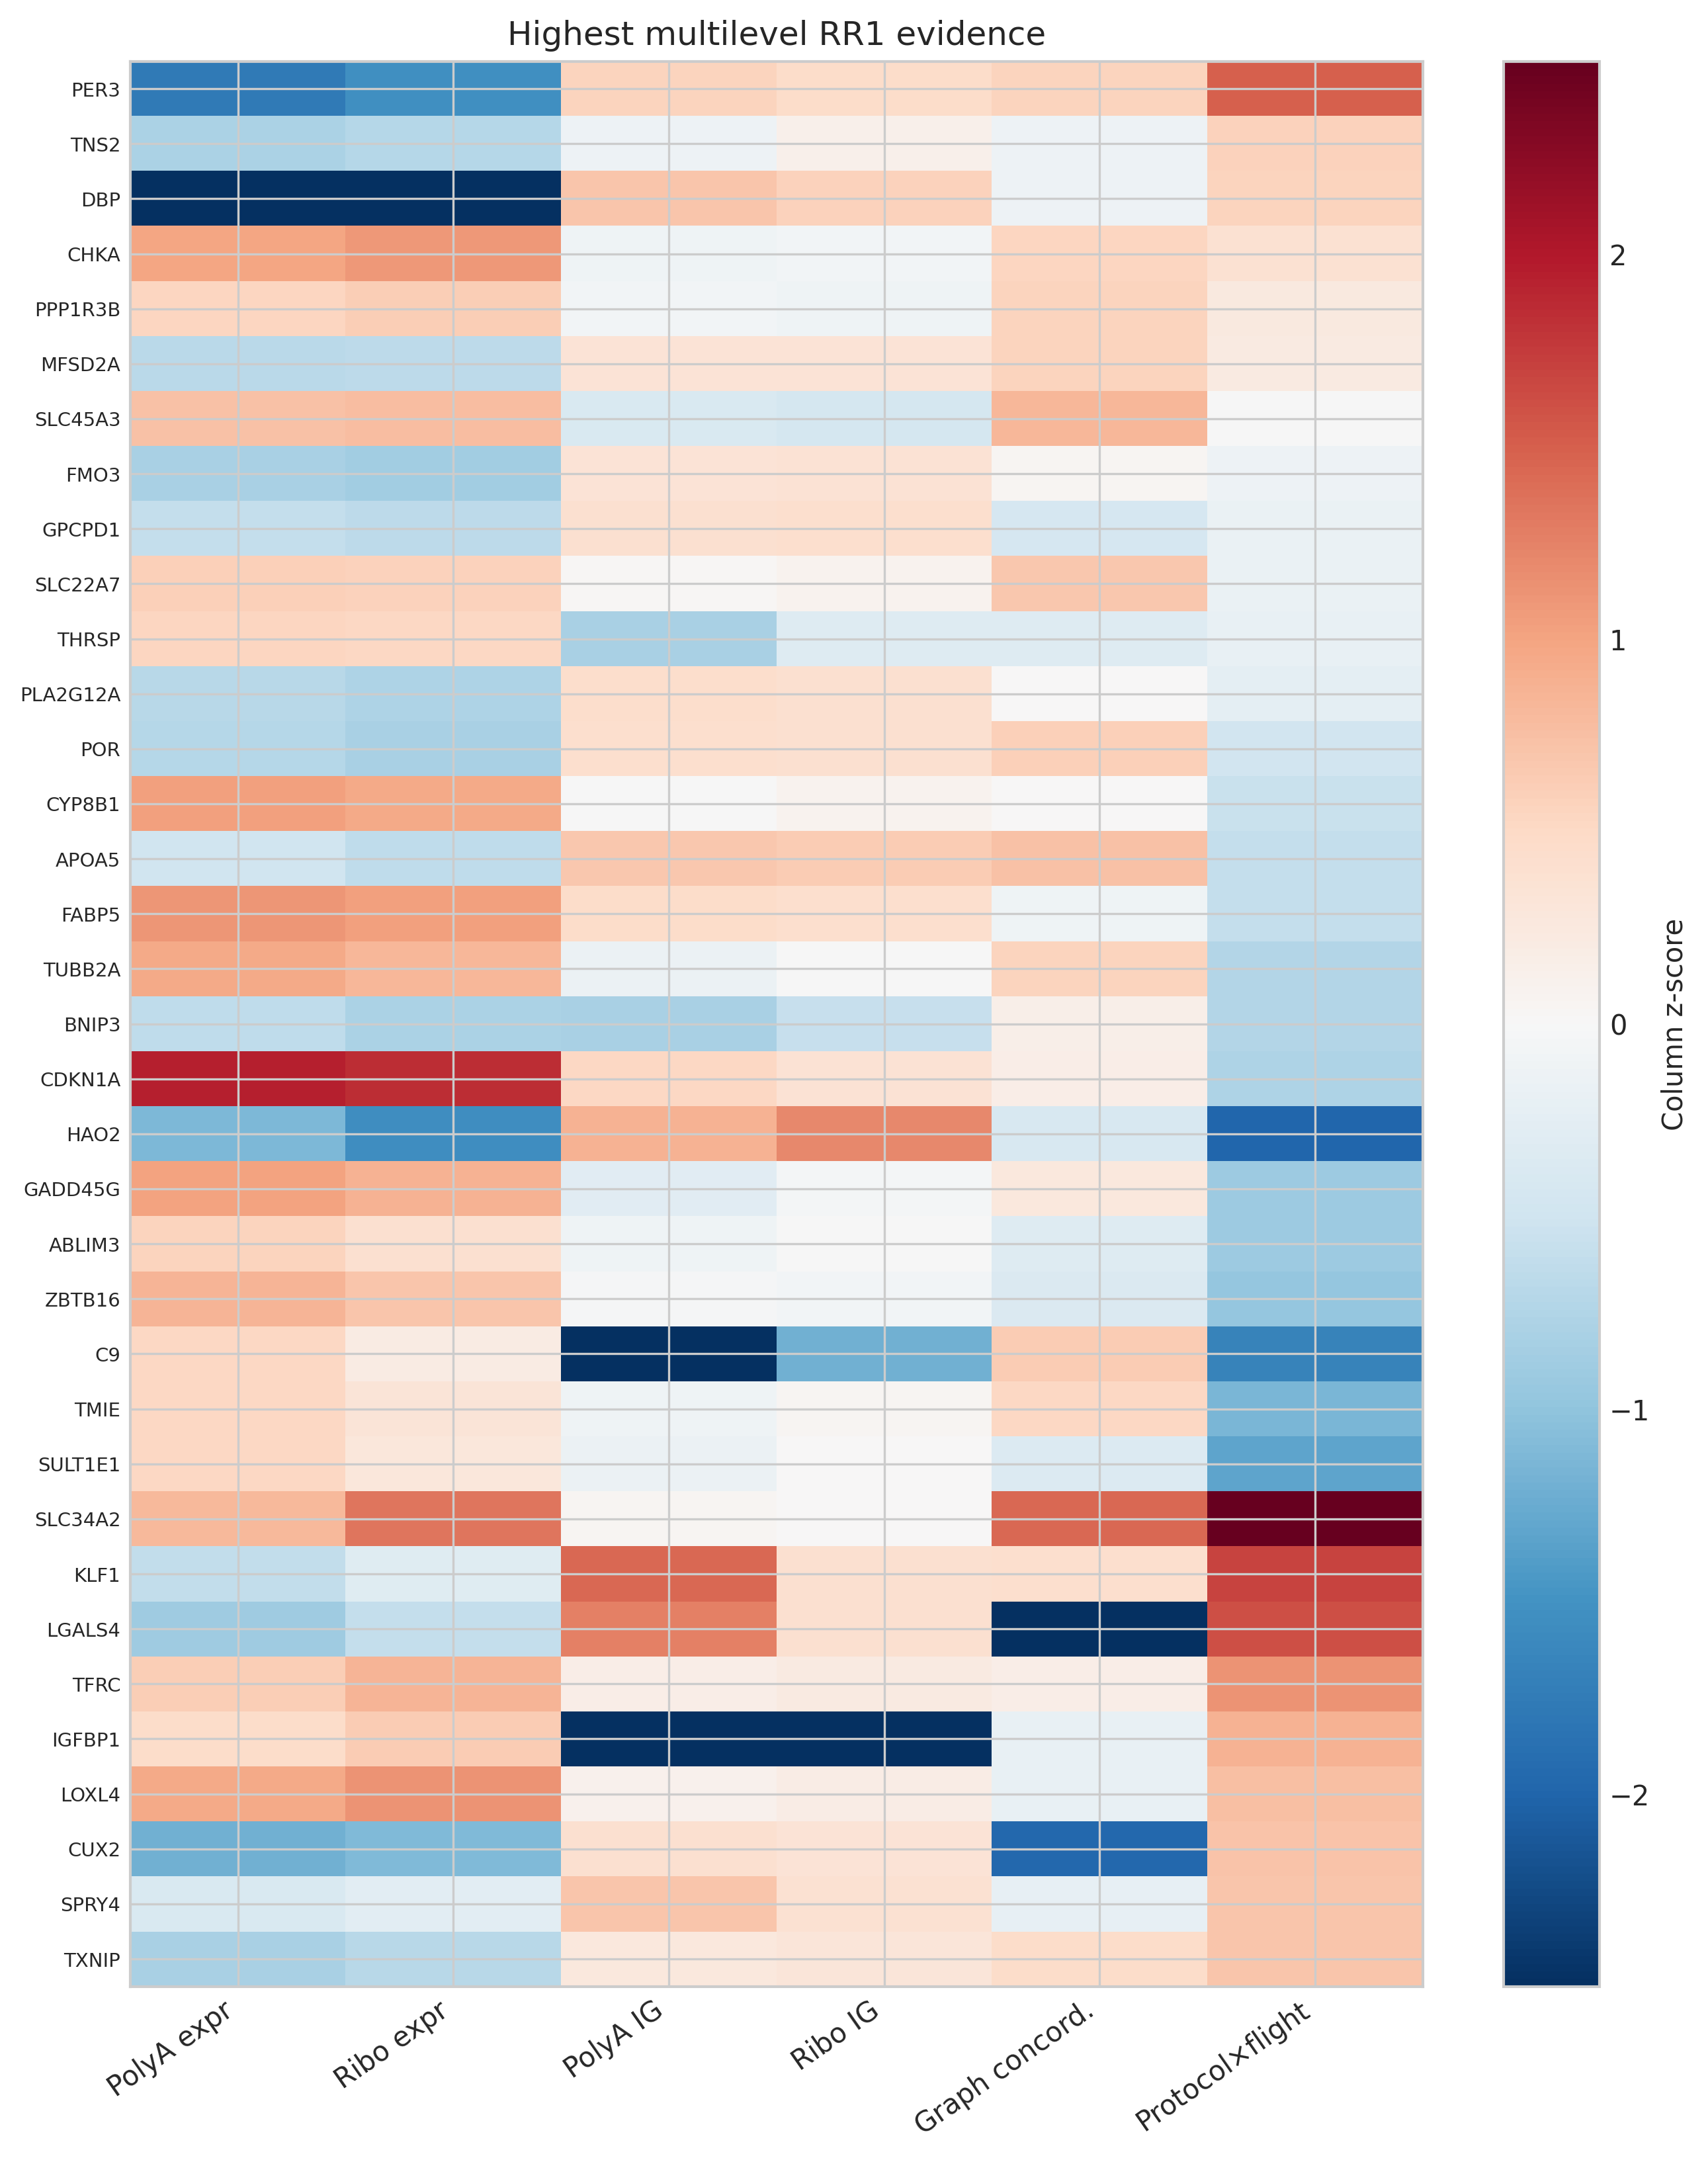

In [16]:
display(Image(filename=str(CORE/'figures/biological_core_heatmap.png')))

## Handling and positive-control context

Several candidates are flagged as handling-sensitive because the small OSD-48 carcass and upon-euthanasia responses differ in sign or fall within the Top-500 subgroup differences. This is a warning flag, not an exclusion: the euthanasia samples lack matched OSD-168 remeasurements.

RR3-40 provides the strongest positive-control expectation, with 172 genes supported by at least two levels and 31 by all three, versus RR1's 114 and 26. RR3-39 has 104 and 15. Core size alone is not a quality metric, but RR3-40 also has markedly stronger genome-wide expression, attribution, program, and graph reproducibility.

## What RR1 biology remains defensible?

Yes, a restricted reproducible RR1 response exists beneath the technical instability. The most defensible evidence concerns hepatic lipid/fatty-acid and peroxisomal metabolism, PPARα-associated regulation, cholesterol/triglyceride biology, transport, circadian regulation, mitochondrial respiration, and selected stress-response genes. These conclusions are supported by same-direction effects across both measurements and by multiple frozen BridgeRNA readouts.

They should be called **protocol-robust within these two RR1 measurements**, not protocol-independent or the uniquely true spaceflight response. RNA-processing/splicing biology is much more prominent among the protocol×flight interaction genes and therefore remains especially measurement-sensitive in RR1.

## Final interpretation

1. **Technical displacement:** very large and nearly parallel in FLT and GC, indicating a strong common protocol shift.
2. **Interaction:** nevertheless large relative to that shift and maximal in the exact condition-label permutation test. The estimated flight response changes with measurement context.
3. **T-cell similarity:** strong in global embedding space, but weaker in expression and absent in the contextual graph interaction. Cross-tissue universality is not established.
4. **Residual response:** removing only the independently learned mean T-cell direction does not restore RR1; global cosine remains negative.
5. **Biology:** RNA processing/splicing dominates the largest expression-interaction genes, with additional metabolic candidates. These are programs whose measurement/representation is sensitive—not automatically technical artifacts.
6. **Handling/RIN:** handling cannot be tested with a matched OSD-168 euthanasia counterpart; available RIN results do not explain the interaction.
7. **Decision:** **mixed**—a substantial generic protocol displacement, a condition-dependent protocol×flight interaction, and deeper RR1 instability remain. The data cannot isolate PolyA/ribodepletion causally from the broader OSD-48→OSD-168 transition.

The strongest justified conclusion is: *RR1 contains a large common PolyA/ribodepletion-associated displacement, but the FLT and GC measurements are not shifted identically enough to preserve the inferred spaceflight response. Removing the independently measured mean technical direction explains only part of the reversal.*